Extracting parameters from calibration_CenterSpellerMVEP_VPiac.vhdr...
Setting channel info structure...
Reading 0 ... 393259  =      0.000 ...   786.518 secs...


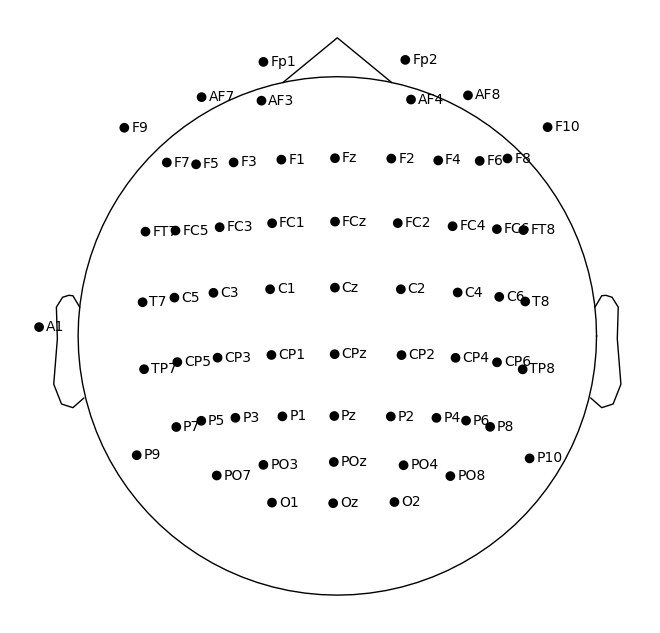

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 sec)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Used Annotations descriptions: ['New Segment/S  0', 'Response/R -1', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 16', 'Stimulus/S 21', 'Stimulus/S 22', 'Stimulus/S 23', 'Stimulus/S 24', 'Stimulus/S 25', 'Stimulus/S 26', 'Stimulus/S 31', 'Stimulus/S 32', 'Stimulus/S 33', 'Stimulus/S 34', 'Stimulus/S 35', 'Stimulus/S 36', 'Stimulus/S 41', 'Stimulus/S 42', 'Stimulus/S 43', 'Stimulus/S 44', 'Stimulus/S 45', 'Stimulus/S 51', 'Stimulus/S 52', 'Stimulus/S 53', 'Stimulus/S 54', 'Stimulus/S 55', 'Stimulus/S 56', 'Stimulus/S 61', 'Stimulus/S 62', 'Stimulus/S 63', 'Stimulus/S 64', 'Stimulus/S 65', 'Stimulus/S240', 'Stimulus/S244', 'Stimulus/S245', 'Stimulus/S246', 'Stimulus/S252']
Not setting metadata
4413 matching events found
Setting baseline interval to [-0.2, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 4413 events and 351 original time points ...
2 bad epochs dropped
Usin

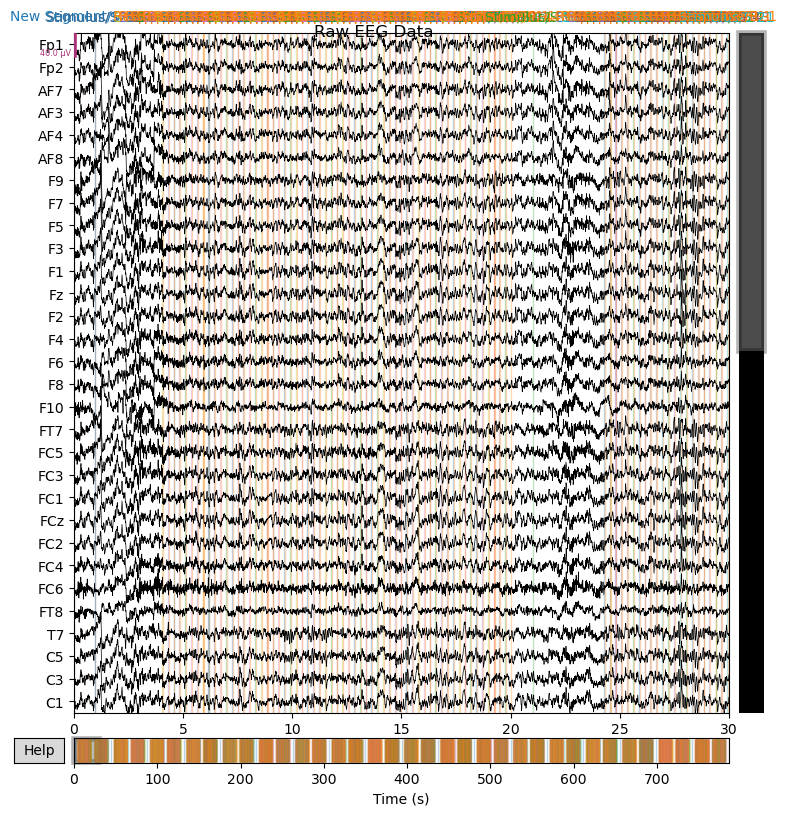

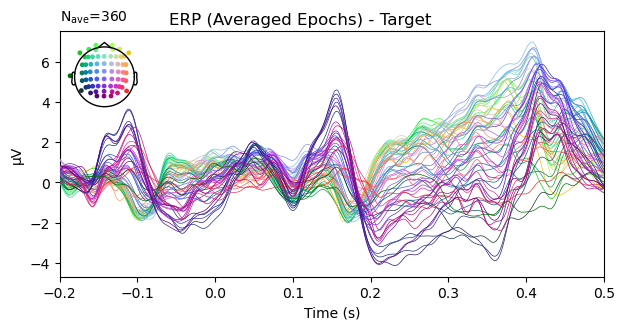

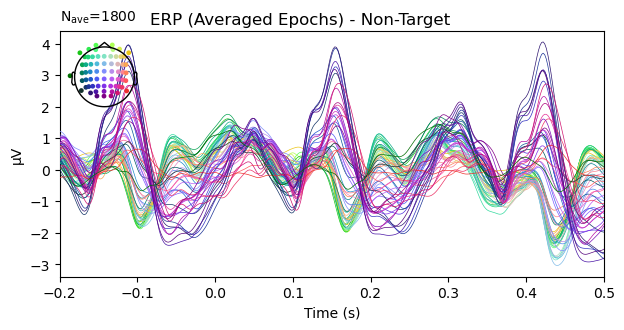

No projector specified for this dataset. Please consider the method self.add_proj.


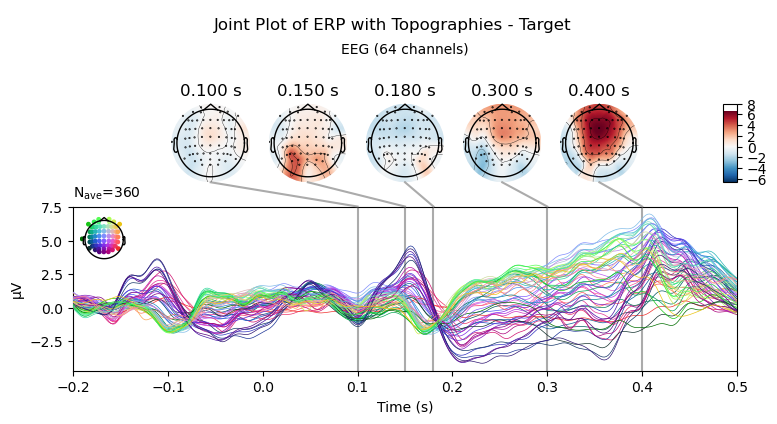

No projector specified for this dataset. Please consider the method self.add_proj.


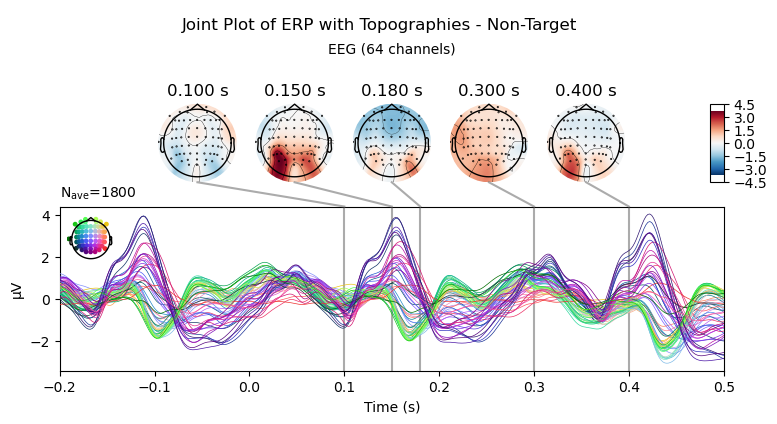

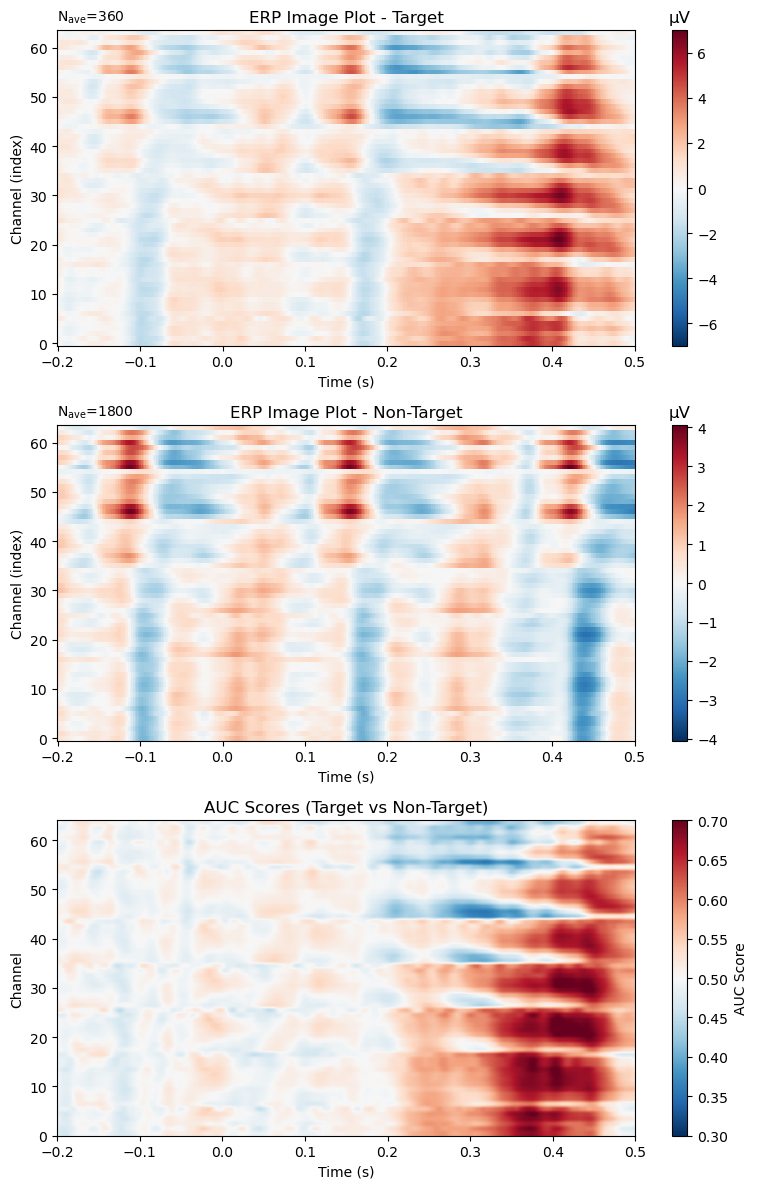

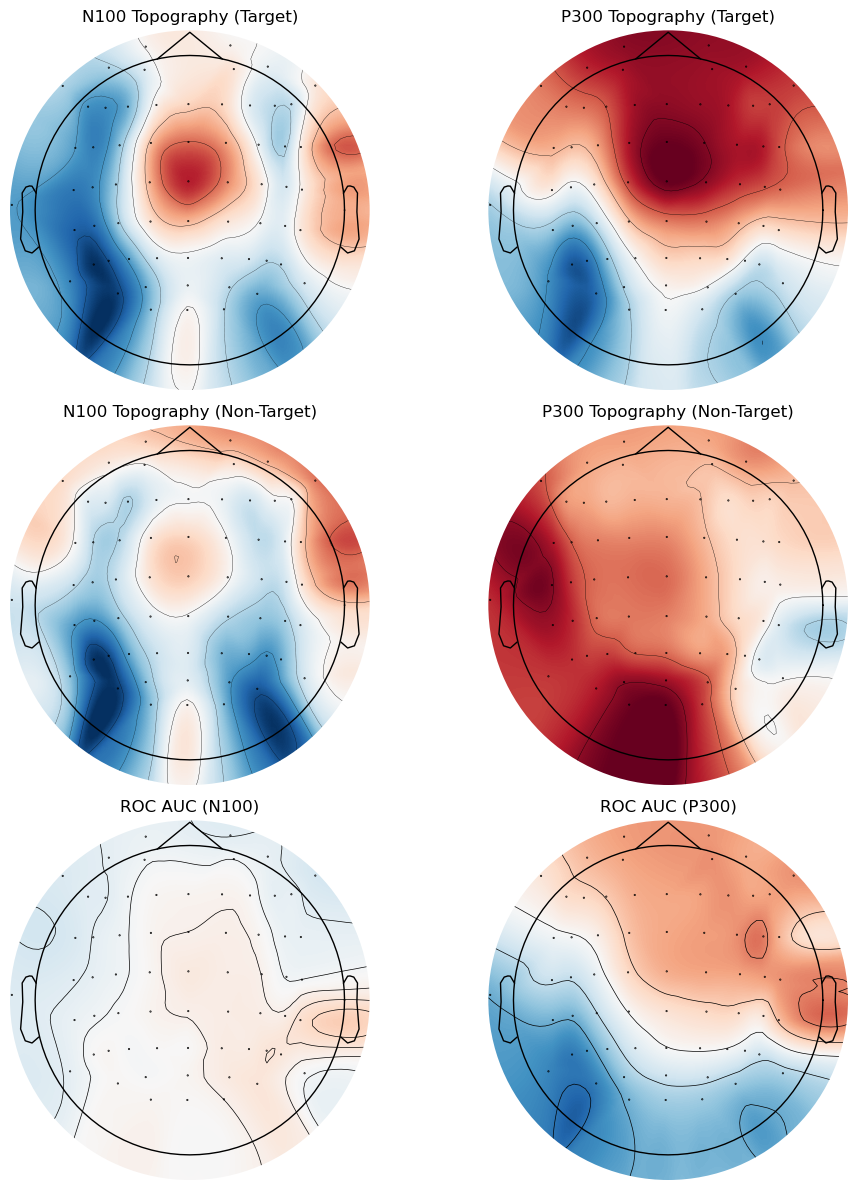

In [1]:
##%%
!pip install mne
import mne
import matplotlib.pyplot as plt
import numpy as np
from mne.io import read_raw_brainvision
from mne.decoding import Vectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from scipy.linalg import eig
from sklearn.decomposition import PCA
from sklearn.utils import resample


# 0. Load and Preprocess Data

loadpath = 'data/'
filename = 'calibration_CenterSpellerMVEP_VPiac'

# Replace with the path to your BrainVision .vhdr file
raw = read_raw_brainvision(filename + '.vhdr', preload=True)


# 1. Set Montage and plot a small segment of the data

# After loading your raw BrainVision data, add a standard montage.
# This will provide the necessary digitization points for scalp plotting.
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

# Plot the sensor locations in 2D using the info from raw.
mne.viz.plot_sensors(raw.info, ch_type='eeg', show_names=True)
plt.show()


# 2.  Apply band-pass filtering (common ERP range is 1-40 Hz)
raw.filter(l_freq=1., h_freq=40., fir_design='firwin')

# 3. Extract events (using all available markers)
events, _ = mne.events_from_annotations(raw)

# Create epochs without filtering by event_id
epochs = mne.Epochs(raw, events, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), preload=True)

# 4. Define marker ranges
target_ids = list(range(31, 47))    # markers 31 to 46
nontarget_ids = list(range(11, 27))   # markers 11 to 26

# 5. Filter epochs based on marker codes
target_epochs = epochs[np.in1d(epochs.events[:, 2], target_ids)]
nontarget_epochs = epochs[np.in1d(epochs.events[:, 2], nontarget_ids)]

# 6. Compute evoked responses (averaging the epochs)
evoked_target = target_epochs.average()
evoked_nontarget = nontarget_epochs.average()

##%%

# ---------------------------
# 7. Plotting
# ---------------------------
# 7.1. Raw Data Plot
raw_fig = raw.plot(duration =30, n_channels=30, show=False)
raw_fig.suptitle('Raw EEG Data')
plt.show()


# 7.2. ERP Plot for Target Condition
target_fig = evoked_target.plot(show=False)
target_fig.axes[0].set_title("")
target_fig.suptitle('ERP (Averaged Epochs) - Target')
plt.show()

# 7.3. ERP Plot for Non-Target Condition
nontarget_fig = evoked_nontarget.plot(show=False)
nontarget_fig.axes[0].set_title("")
nontarget_fig.suptitle('ERP (Averaged Epochs) - Non-Target')
plt.show()



# 7.4. Joint Plot: Combines ERP waveform with topographies at key time points
joint_fig = evoked_target.plot_joint(times=[0.1, 0.15, 0.18, 0.3, 0.4], show=False)
joint_fig.suptitle('Joint Plot of ERP with Topographies - Target')
plt.show()

joint_fig = evoked_nontarget.plot_joint(times=[0.1, 0.15, 0.18, 0.3, 0.4], show=False)
joint_fig.suptitle('Joint Plot of ERP with Topographies - Non-Target')
plt.show()

##%%
# 7.5 ERP matrix

target_data = target_epochs.get_data()
nontarget_data = nontarget_epochs.get_data()

num_channels = target_data.shape[1]
num_times = target_data.shape[2]
auc_matrix = np.zeros((num_channels, num_times))

for channel in range(num_channels):
    for time_point in range(num_times):
        target_vals = target_data[:, channel, time_point]
        nontarget_vals = nontarget_data[:, channel, time_point]

        true_labels = np.concatenate([np.ones(len(target_vals)), np.zeros(len(nontarget_vals))])
        prediction_scores = np.concatenate([target_vals, nontarget_vals])
        auc_matrix[channel, time_point] = roc_auc_score(true_labels, prediction_scores)

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

evoked_target.plot_image(show=False, axes=axes[0])
axes[0].set_title('ERP Image Plot - Target')

evoked_nontarget.plot_image(show=False, axes=axes[1])
axes[1].set_title('ERP Image Plot - Non-Target')

im = axes[2].imshow(auc_matrix,
                    aspect='auto',
                    origin='lower',
                    extent=[evoked_target.times[0], evoked_target.times[-1], 0, num_channels],
                    vmin=0.3,
                    vmax=0.7,
                    cmap='RdBu_r')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Channel')
plt.colorbar(im, ax=axes[2], label='AUC Score')
axes[2].set_title('AUC Scores (Target vs Non-Target)')

plt.tight_layout()
plt.show()

##%%
# 7.6 Comparison of ERP data in a scalp map
n100_time = 0.1
p300_time = 0.3

num_channels = target_data.shape[1]
num_times = target_data.shape[2]
auc_n100_scores = np.zeros(num_channels)
auc_p300_scores = np.zeros(num_channels)

for channel in range(num_channels):
    target_vals_n100 = target_data[:, channel, np.argmin(np.abs(evoked_target.times - n100_time))]
    nontarget_vals_n100 = nontarget_data[:, channel, np.argmin(np.abs(evoked_target.times - n100_time))]

    true_labels_n100 = np.ones(len(target_vals_n100))
    true_labels_n100 = np.concatenate([true_labels_n100, np.zeros(len(nontarget_vals_n100))])

    prediction_scores_n100 = np.concatenate([target_vals_n100, nontarget_vals_n100])
    auc_n100_scores[channel] = roc_auc_score(true_labels_n100, prediction_scores_n100)

    target_vals_p300 = target_data[:, channel, np.argmin(np.abs(evoked_target.times - p300_time))]
    nontarget_vals_p300 = nontarget_data[:, channel, np.argmin(np.abs(evoked_target.times - p300_time))]

    true_labels_p300 = np.ones(len(target_vals_p300))
    true_labels_p300 = np.concatenate([true_labels_p300, np.zeros(len(nontarget_vals_p300))])

    prediction_scores_p300 = np.concatenate([target_vals_p300, nontarget_vals_p300])

    auc_p300_scores[channel] = roc_auc_score(true_labels_p300, prediction_scores_p300)

from matplotlib.colors import TwoSlopeNorm
vmax = 0.7
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

evoked_target.plot_topomap(times=n100_time, ch_type='eeg', axes=axes[0, 0], colorbar=False, show=False)
axes[0, 0].set_title('N100 Topography (Target)')

evoked_target.plot_topomap(times=p300_time, ch_type='eeg', axes=axes[0, 1], colorbar=False, show=False)
axes[0, 1].set_title('P300 Topography (Target)')

# Row 1: Non-target ERP
evoked_nontarget.plot_topomap(times=n100_time, ch_type='eeg', axes=axes[1, 0], colorbar=False, show=False)
axes[1, 0].set_title('N100 Topography (Non-Target)')

evoked_nontarget.plot_topomap(times=p300_time, ch_type='eeg', axes=axes[1, 1], colorbar=False, show=False)
axes[1, 1].set_title('P300 Topography (Non-Target)')

mne.viz.plot_topomap(
    auc_n100_scores,
    evoked_target.info,
    axes=axes[2, 0],
    cmap='RdBu_r',
    cnorm=TwoSlopeNorm(vmin=0.3, vcenter=0.5, vmax=vmax),
    contours=6,
    show=False
)
axes[2, 0].set_title('ROC AUC (N100)')

# P300
mne.viz.plot_topomap(
    auc_p300_scores,
    evoked_target.info,
    axes=axes[2, 1],
    cmap='RdBu_r',
    cnorm=TwoSlopeNorm(vmin=0.3, vcenter=0.5, vmax=vmax),
    contours=6,
    show=False
)
axes[2, 1].set_title('ROC AUC (P300)')

plt.tight_layout()
plt.show()

##%%


## NCC

In [3]:
def make_features(X, mode):
    if mode == 'temporal':
        X_feat = X.mean(axis=1)
    elif mode == 'spatial':
        X_feat = X.mean(axis=2)
    else:
        X_feat = X.reshape(X.shape[0], -1)
    return X_feat

def ncc_batch_train(X, Y):
    cids = np.unique(Y)
    mu = np.zeros((X.shape[0], len(cids)))
    for idx, cid in enumerate(cids):
        mu[:, idx] = X[:, Y == cid].mean(axis=1)
    return mu

def predict_ncc(X, mu):
    NCdist = np.sum((X[:, :, np.newaxis] - mu[:, np.newaxis, :])**2, axis=0)
    return NCdist

def crossval_ncc(X, y, mode='spatio-temporal', n_splits=5):
    Kfold = StratifiedKFold(n_splits=n_splits)
    auc_scores = []

    for train_idx, test_idx in Kfold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        vectorizer = Vectorizer()
        X_train_feat = vectorizer.fit_transform(make_features(X_train, mode)).T
        X_test_feat = vectorizer.transform(make_features(X_test, mode)).T

        mu = ncc_batch_train(X_train_feat, y_train)
        NC_dist = predict_ncc(X_test_feat, mu)

        prob_class_0 = 1 / (1 + NC_dist[:, 1])
        auc_scores.append(roc_auc_score(y_test, prob_class_0))
        accuracy = np.mean(auc_scores)
    return accuracy

scores_NCC = []
print("\nNCC Results:")
for mode in ['temporal', 'spatial', 'spatio-temporal']:
    X = np.concatenate([target_data, nontarget_data], axis=0)
    y = np.concatenate([np.ones(target_data.shape[0]), np.zeros(nontarget_data.shape[0])])

    auc = crossval_ncc(X, y, mode=mode, n_splits=5)
    scores_NCC.append(auc.item())
    print(f"NCC - {mode} : {auc}")



NCC Results:
NCC - temporal : 0.5724845679012345
NCC - spatial : 0.5632870370370371
NCC - spatio-temporal : 0.5926697530864198


## LDA

In [ ]:
def balance_classes(X, y):
    X_flat = X.reshape(X.shape[0], -1)
    X_y = np.hstack((X_flat, y.reshape(-1, 1)))
    majority_class, minority_class = [X_y[X_y[:, -1] == cls] for cls in np.unique(y)]

    majority_undersampled = resample(majority_class, replace=False, n_samples=len(minority_class), random_state=42)
    X_balanced, y_balanced = np.vstack((majority_undersampled, minority_class))[:, :-1], np.vstack((majority_undersampled, minority_class))[:, -1]

    return X_balanced.reshape(-1, X.shape[1], X.shape[2]), y_balanced


def crossval_lda(X, y, n_splits=5, mode='spatio-temporal'):
    Kfold = StratifiedKFold(n_splits=n_splits)
    auc_scores = []

    for train_idx, test_idx in Kfold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train, y_train = balance_classes(X_train, y_train)
        vectorizer = Vectorizer()
        X_train_feat = vectorizer.fit_transform(X_train)
        X_test_feat = vectorizer.transform(X_test)

        if mode == 'spatio-temporal':
            pca = PCA(n_components=0.93, svd_solver='full')
            X_train_feat, X_test_feat = pca.fit_transform(X_train_feat), pca.transform(X_test_feat)

        lda = LinearDiscriminantAnalysis(solver='svd', priors=[0.5, 0.5])
        lda.fit(X_train_feat, y_train)

        pred = roc_auc_score(y_test, lda.predict_proba(X_test_feat)[:, -1])

        auc_scores.append(pred)
        accuracy = np.mean(auc_scores)
    return accuracy


print("\nLDA results:")
scores_LDA = []
for mode in ['temporal', 'spatial', 'spatio-temporal']:
    X = np.concatenate([target_data, nontarget_data], axis=0)
    y = np.concatenate([np.ones(target_data.shape[0]), np.zeros(nontarget_data.shape[0])])
    y = 2 * y - 1

    auc = crossval_lda(X, y, n_splits=8, mode=mode)
    scores_LDA.append(auc.item())
    print(f"LDA - {mode} : {auc}")



LDA results:


In [19]:
def balance_classes(X, y):
    X_flat = X.reshape(X.shape[0], -1)
    X_y = np.hstack((X_flat, y.reshape(-1, 1)))
    majority_class, minority_class = [X_y[X_y[:, -1] == cls] for cls in np.unique(y)]

    majority_undersampled = resample(majority_class, replace=False, n_samples=len(minority_class), random_state=42)
    X_balanced, y_balanced = np.vstack((majority_undersampled, minority_class))[:, :-1], np.vstack((majority_undersampled, minority_class))[:, -1]

    return X_balanced.reshape(-1, X.shape[1], X.shape[2]), y_balanced

def crossval_rlda(X, y, n_splits=5, mode='spatio-temporal'):
    skf = StratifiedKFold(n_splits=n_splits)
    auc_list = []

    for train_idx, test_idx in skf.split(X, y):
        Xtrain, Xtest = X[train_idx], X[test_idx]
        ytrain, ytest = y[train_idx], y[test_idx]

        Xtrain, ytrain = balance_classes(Xtrain, ytrain)

        vectorizer = Vectorizer()

        Xtrain_feat = vectorizer.fit_transform(Xtrain)
        Xtest_feat = vectorizer.transform(Xtest)

        pca = PCA(n_components=0.93, svd_solver='full')
        Xtrain_feat_pca = pca.fit_transform(Xtrain_feat)
        Xtest_feat_pca = pca.transform(Xtest_feat)


        rlda = LinearDiscriminantAnalysis(solver='eigen', shrinkage=0.5)
        rlda.fit(Xtrain_feat_pca, ytrain)
        y_pred_prob = rlda.predict_proba(Xtest_feat_pca)[:, -1]

        auc = roc_auc_score(ytest, y_pred_prob)
        auc_list.append(auc)

    return np.mean(auc_list)


print("\nRLDA results:")
scores_RLDA = []
for mode in ['temporal', 'spatial', 'spatio-temporal']:
    X = np.concatenate([target_data, nontarget_data], axis=0)
    y = np.concatenate([np.ones(target_data.shape[0]), np.zeros(nontarget_data.shape[0])])
    y = 2 * y - 1
    auc = crossval_rlda(X, y, n_splits=8, mode=mode)
    scores_RLDA.append(auc.item())
    print(f"RLDA - {mode} : {auc}")



RLDA results:
RLDA - temporal : 0.8346172839506173
RLDA - spatial : 0.8346172839506173
RLDA - spatio-temporal : 0.8346172839506173


## LOGREG

In [20]:
def crossval_logreg(X, y, n_splits=5, mode = "spatio-temporal", its=100, eta=0.01):

    skf = StratifiedKFold(n_splits=n_splits)
    auc_list = []

    for train_idx, test_idx in skf.split(X, y):
        Xtrain, Xtest = X[train_idx], X[test_idx]
        ytrain, ytest = y[train_idx], y[test_idx]

        vectorizer = Vectorizer()

        Xtrain_feat = vectorizer.fit_transform(Xtrain)
        Xtest_feat = vectorizer.transform(Xtest)

        if mode == 'spatio-temporal':
            pca = PCA(n_components=0.93, svd_solver='full')
            Xtrain_feat_pca = pca.fit_transform(Xtrain_feat)
            Xtest_feat_pca = pca.transform(Xtest_feat)
        else:
            Xtrain_feat_pca = Xtrain_feat
            Xtest_feat_pca = Xtest_feat

        logreg = LogisticRegression(solver='lbfgs', max_iter=1000)
        logreg.fit(Xtrain_feat_pca, ytrain)

        y_pred_prob = logreg.predict_proba(Xtest_feat_pca)[:, -1]
        auc = roc_auc_score(ytest, y_pred_prob)
        auc_list.append(auc)

    return np.mean(auc_list)



scores_LogReg = []
for mode in ['temporal', 'spatial', 'spatio-temporal']:
    X = np.concatenate([target_data, nontarget_data], axis=0)
    y = np.concatenate([np.ones(target_data.shape[0]), np.zeros(nontarget_data.shape[0])])

    auc = crossval_logreg(X, y, n_splits=5, mode=mode)
    scores_LogReg.append(auc.item())
    print(f"LogReg - {mode} : {auc}")


LogReg - temporal : 0.7546373456790123
LogReg - spatial : 0.7546373456790123
LogReg - spatio-temporal : 0.7490895061728395


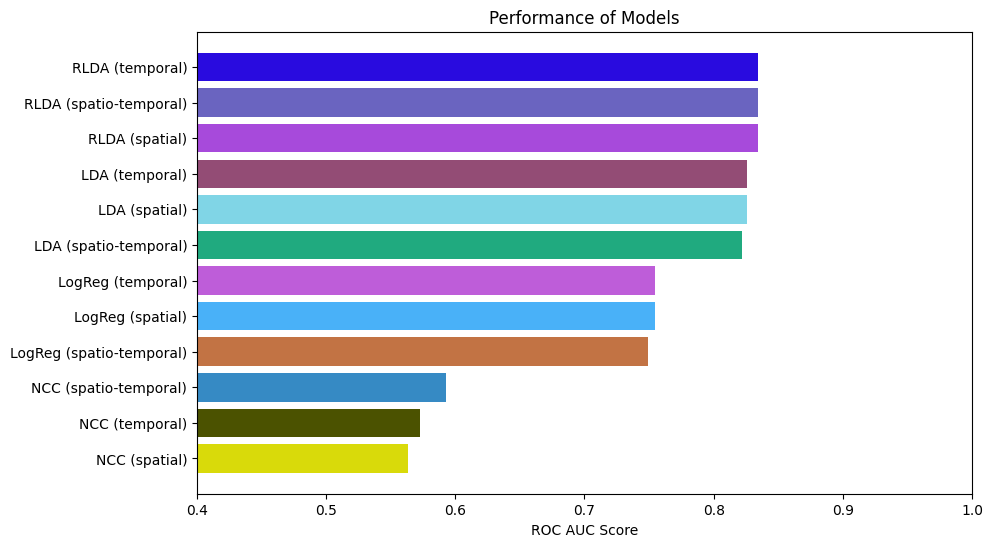

In [31]:
scores_all = [ scores_NCC, scores_LDA, scores_RLDA, scores_LogReg]
flattened_scores = [score for sublist in scores_all for score in sublist]

scores_for_models = {
    "NCC": flattened_scores[:3],
    "LDA": flattened_scores[3:6],
    "RLDA": flattened_scores[6:9],
    "LogReg": flattened_scores[9:]
}

modes = ["temporal", "spatial", "spatio-temporal"]
plot_labels = []
model_scores = []

for model, scores in scores_for_models.items():
    for mode, score in zip(modes, scores):
        plot_labels.append(f"{model} ({mode})")
        model_scores.append(score)

sorted_scores_with_labels = sorted(zip(model_scores, plot_labels))
sorted_scores, sorted_labels = zip(*sorted_scores_with_labels)
random_colors = np.random.rand(len(sorted_scores), 3)

plt.figure(figsize=(10, 6))
plt.barh(sorted_labels, sorted_scores, color=random_colors)
plt.xlabel("ROC AUC Score")
plt.title("Performance of Models")
plt.xlim(0.4, 1.0)
plt.show()